Generating data similar to gen data

Everything else is binomial except outcome 

In [116]:
import pandas as pd
import numpy as np
import random as rn
import matplotlib.pyplot as plt
import networkx as nx
from dowhy import CausalModel
from castle.algorithms import PC
from castle.common import GraphDAG

In [117]:
num_samples=10000

A

In [118]:
p = 0.25
np.random.seed(42)
A = np.random.binomial(1, p, num_samples)

B

In [119]:
q = 0.20
np.random.seed(42)
B = np.random.binomial(1, q, num_samples)

C

In [120]:
r = 0.69
np.random.seed(42)
C = np.random.binomial(1, r, num_samples)

D

In [121]:
s=0.73
np.random.seed(42)
D=np.random.binomial(1,s,num_samples)

E

In [122]:
t=0.90
np.random.seed(42)
E=np.random.binomial(1,t,num_samples)

Making 1 big dataframe

In [123]:
df=pd.DataFrame([A, B, C, D, E])
df.index=["A","B","C","D","E"]
df=df.T

In [124]:
df.head()

,A,B,C,D,E
0,0,0,1,1,1
1,1,1,0,0,0
2,0,0,0,0,1
3,0,0,1,1,1
4,0,0,1,1,1


Adding a yes or no value for treatment


Note: Formula is Treatment= Noise + 0.45A + 0.15E + 1.3D

In [125]:
np.random.seed(42)
noise_t = np.random.normal(0, 0.1, num_samples)
t = np.sum([noise_t] + [0.45*A] + [0.15*E] + [1.32*D], axis=0)

In [126]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def convert_to_binary(x, stochastic=True):
    p = sigmoid(x)
    if stochastic:
        return np.random.choice([0, 1], 1, p=[1 - p, p])
    else:
        return int(p > 0.5)

In [127]:
t_bin = np.array([convert_to_binary(x) for x in t]).flatten()

In [128]:
df['Treatment'] = t_bin

Adding Outcome values

Note: The right formula used here is Outcome= Noise + 5*Treatment + 0.33*A + 0.39*E + 0.02*B

In [129]:
np.random.seed(42)
noise_out = np.random.normal(0, 0.1, num_samples)
out = np.sum([noise_out] + [5*t_bin] + [0.33*A] + [0.39*E] + [0.02*B*t_bin], axis=0)

In [130]:
df['Outcome'] = out

In [131]:
df

,A,B,C,D,E,Treatment,Outcome
0,0,0,1,1,1,1,5.439671
1,1,1,0,0,0,0,0.316174
2,0,0,0,0,1,0,0.454769
3,0,0,1,1,1,0,0.542303
4,0,0,1,1,1,1,5.366585
...,...,...,...,...,...,...,...
9995,1,1,0,0,1,1,5.870110
9996,1,1,0,0,1,1,5.540166
9997,1,1,0,0,0,0,0.259468
9998,0,0,1,1,1,1,5.439577


Saving this dataframe

In [132]:
df.to_csv("og_new_gen_data_binomial_except_outcome_10000_alpha_0.05.csv", index=False)

Running PC algorithm

In [133]:
pc= PC(alpha=0.05)
pc.learn(df)

In [134]:
pc.causal_matrix

Tensor([[0, 1, 0, 1, 0, 1, 1],
        [1, 0, 0, 0, 1, 0, 0],
        [0, 0, 0, 1, 0, 0, 0],
        [1, 0, 1, 0, 0, 0, 1],
        [0, 0, 0, 0, 0, 1, 1],
        [0, 0, 0, 0, 0, 0, 0],
        [0, 0, 0, 0, 0, 1, 0]])

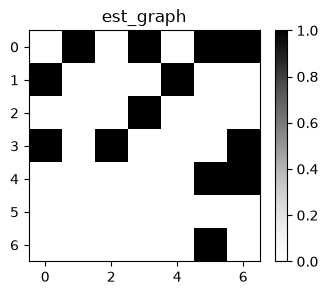

In [135]:
GraphDAG(est_dag=pc.causal_matrix)

In [136]:
import utils_causal

nodes = df.columns
labels = nodes

nodes_labels = [(n, n) for n in nodes]

edges = []
for i, start_node in enumerate(nodes):
    for j, end_node in enumerate(nodes):
        if pc.causal_matrix[i, j] == 1:
            edges.append((start_node, end_node))

2026-08-04 11:01:13,602 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\causal_model.py[line:506] - INFO: Model to find the causal effect of treatment ['Treatment'] on outcome ['Outcome']
2026-08-04 11:01:13,606 - c:\Users\gk442\AppData\Local\miniconda3\envs\causal\Lib\site-packages\dowhy\utils\plotting.py[line:84] - INFO: Pygraphviz installation not found, falling back to networkx plotting. For better looking plots, consider installing pygraphviz. Note This requires both the Python pygraphviz package (``pip install pygraphviz``) and the shared system library (e.g. ``brew install graphviz`` or ``apt-get install graphviz``)


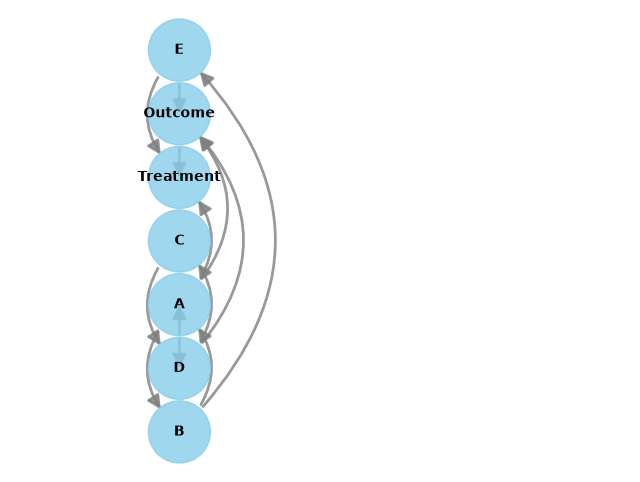

In [137]:
model_test = utils_causal.make_causalmodel_object(nodes_labels, edges)
model_test.view_model()

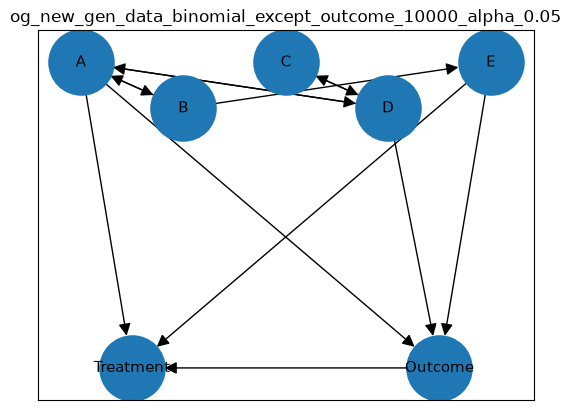

In [138]:
adj_matrix= np.array(pc.causal_matrix)

node_names=df.columns

G=nx.from_numpy_array(adj_matrix, create_using=nx.DiGraph)

mapping={i:node_names[i] for i in range(len(node_names))}
G=nx.relabel_nodes(G, mapping)

pos={
    "A":(1,1),
    "B":(2,0.85),
    "C":(3,1),
    "D":(4,0.85),
    "E":(5,1),
    "Treatment":(1.5,0),
    "Outcome":(4.5,0)
}

nx.draw_networkx(
    G,
    pos,
    with_labels=True,
    arrows=True,
    node_size=2200,
    font_size=11,
    arrowsize=18
)

plt.title("og_new_gen_data_binomial_except_outcome_10000_alpha_0.05")
plt.savefig("og_new_gen_data_binomial_except_outcome_10000_alpha_0.05.png")
plt.show()